In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from matplotlib.pyplot import rcParams
%matplotlib inline
rcParams["figure.figsize"] = 15, 6

In [2]:
# ######################################
# 读取数据为 DataFrame
# ######################################
dateparse = lambda dates: pd.to_datetime(dates, format = "%Y-%m")
data = pd.read_csv("../data/AirPassengers/AirPassengers.csv",
				   parse_dates = ["Month"],
				   index_col = "Month", 
				   date_parser = dateparse)
print(data.shape)
print("-" * 25)
print(data.head())
print("-" * 25)
print(data.dtypes)
print("-" * 25)
print(data.index)
print("-" * 25)

(144, 1)
-------------------------
            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121
-------------------------
#Passengers    int64
dtype: object
-------------------------
DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)
-------------------------


In [8]:
# #####################################
# 将数据转换为 Series
# #####################################
ts = data["#Passengers"]
print(ts.head())
print("-" * 25)

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: #Passengers, dtype: int64
-------------------------


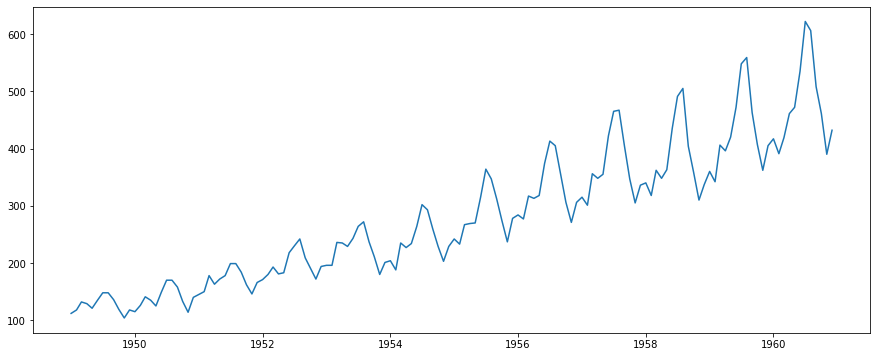

In [9]:
# #####################################
# 时间序列分析——检验时间序列的平稳性
# #####################################
plt.plot(ts);

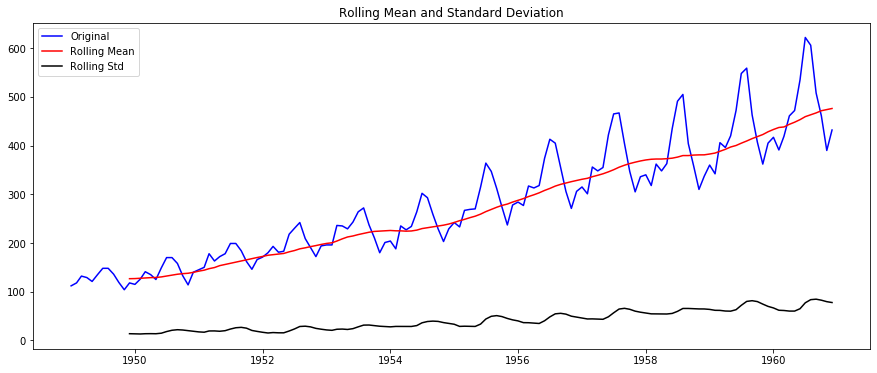

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Cirtical Value (1%)             -3.481682
Cirtical Value (5%)             -2.884042
Cirtical Value (10%)            -2.578770
dtype: float64


In [13]:
# 平稳性检验
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
	# determing rolling statistics
	rolmean = timeseries.rolling(window = 12).mean()
	rolstd = timeseries.rolling(window = 12).std()
    
	# plot rolling statistics
	orig = plt.plot(timeseries, color = "blue", label = "Original")
	mean = plt.plot(rolmean, color = "red", label = "Rolling Mean")
	std = plt.plot(rolstd, color = "black", label = "Rolling Std")
	plt.legend(loc = "best")
	plt.title("Rolling Mean and Standard Deviation")
	plt.show(block = False)

	# perform Dickey-Fuller test
	print("Results of Dickey-Fuller Test:")
	dftest = adfuller(timeseries, autolag = "AIC")
	dfoutput = pd.Series(dftest[0:4], 
						 index = ["Test Statistic", 
						 		  "p-value", 
						 		  "#Lags Used", 
						 		  "Number of Observations Used"])
	for key, value in dftest[4].items():
		dfoutput["Cirtical Value (%s)" % key] = value
	print(dfoutput)

test_stationarity(ts)

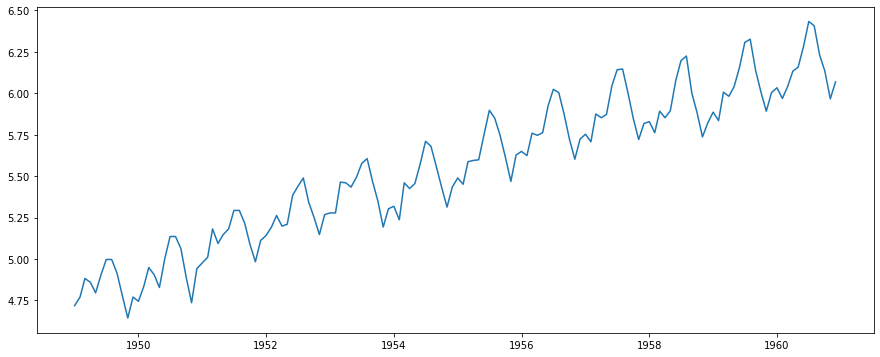

In [15]:
# 消除趋势
ts_log = np.log(ts)
plt.plot(ts_log);

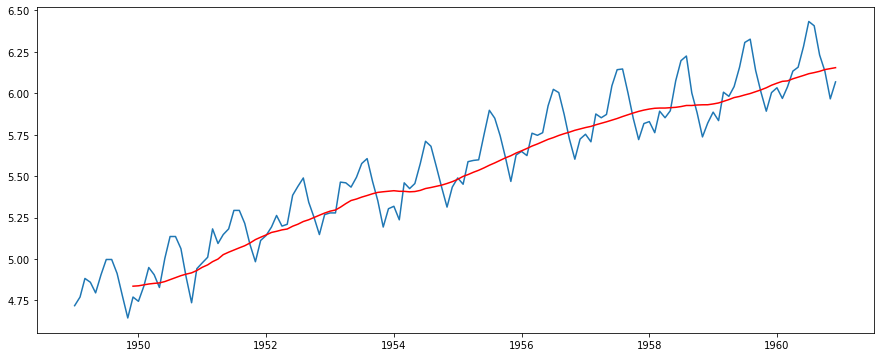

In [16]:
moving_avg = ts_log.rolling(window = 12).mean()
plt.plot(ts_log)
plt.plot(moving_avg, color = "red")